In [1]:
import random
import heapq
import time
from collections import deque
# Terrain Legend
# C = Corridor (cost 1)
# S = Stairs (cost 3)
# L = Lift (cost 2)
# O = Open Ground (cost 1)
# X = Blocked

In [2]:
COST = {'C':1, 'O':1, 'S':3, 'L':2, 'X':float('inf')}
SIZE = 10
TERRAINS = ['C','O','S','L']

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
color_map = {
    'C': '#e0e0e0',  # light gray
    'O': '#c8e6c9',  # light green
    'L': '#bbdefb',  # light blue
    'S': '#ffe0b2',  # light orange
    'X': '#424242'   # blocked dark
}

In [4]:
def draw_grid(title):
    fig, ax = plt.subplots(figsize=(4,4))
    for r in range(SIZE):
        for c in range(SIZE):
            rect = patches.Rectangle((c, r), 1, 1,
                                     facecolor=color_map[grid[r][c]],
                                     edgecolor='black')
            ax.add_patch(rect)
    # Plot Start (only once)
    ax.scatter(start[1] + 0.5, start[0] + 0.5,
               color='green', s=80, label='Start')
    # Plot Goals (label only first one)
    for i, g in enumerate(goals):
        if i == 0:
            ax.scatter(g[1] + 0.5, g[0] + 0.5,
                       color='blue', s=80, label='Goal')
        else:
            ax.scatter(g[1] + 0.5, g[0] + 0.5,
                       color='blue', s=80)
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, SIZE)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(SIZE))
    ax.set_yticks(range(SIZE))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, linewidth=0.5)
    ax.invert_yaxis()
    ax.legend(loc='upper right',
              fontsize=8,
              markerscale=0.7,
              frameon=True,
              borderpad=0.3,
              labelspacing=0.3,
              handletextpad=0.3)

    plt.show()

In [31]:
def generate_grid():
    grid = [[random.choice(TERRAINS) for _ in range(SIZE)] for _ in range(SIZE)]
    blocks = random.randint(20,30) * SIZE * SIZE // 100
    b = 0
    while b < blocks:
        r,c = random.randint(0,SIZE-1), random.randint(0,SIZE-1)
        if grid[r][c] != 'X':
            grid[r][c] = 'X'
            b += 1
    return grid
grid = generate_grid()
start = (0,0)
goals = [(7,9),(5,7)]
grid[0][0] = 'C'

GRID:
C L L O X C X S L S
O X L O L S L L X O
O X X S O C X O X S
O L L C S O C X L C
S O C S L S C C C X
L O S O S L S L X X
X O L L X S O S S O
X L O S X S O O C L
X L X S X X X L X O
C X S L S L L X X O


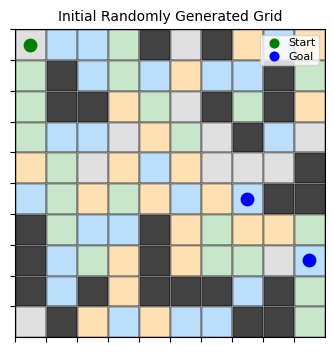

In [32]:
def print_grid(g):
    for row in g:
        print(" ".join(row))
print("GRID:")
print_grid(grid)
draw_grid("Initial Randomly Generated Grid")

In [7]:
def get_neighbors(pos):
    r,c = pos
    moves=[]
    for dr,dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr,nc=r+dr,c+dc
        if 0<=nr<SIZE and 0<=nc<SIZE and grid[nr][nc] != 'X':
            moves.append((nr,nc))
    return moves

In [8]:
def manhattan(a,b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def custom_heuristic(pos,goal):
    penalty=0
    if grid[pos[0]][pos[1]]=='S': penalty+=5
    if grid[pos[0]][pos[1]]=='L': penalty+=3
    return manhattan(pos,goal)+penalty

In [9]:
def visualize(path,title):
    if not path:
        print(f"{title}: NO PATH FOUND")
        return
    p=set(path)
    print(f"\n{title} PATH")
    for r in range(SIZE):
        row=[]
        for c in range(SIZE):
            if (r,c)==start: row.append('S')
            elif (r,c) in goals: row.append('G')
            elif (r,c) in p: row.append('*')
            else: row.append(grid[r][c])
        print(" ".join(row))

In [10]:
def print_path_coords(path, title):
    print(f"\n{title} coordinate path:")
    print(path)

In [11]:
def draw_path(path, title):
    fig, ax = plt.subplots(figsize=(4,4))
    # Draw grid cells
    for r in range(SIZE):
        for c in range(SIZE):
            rect = patches.Rectangle((c, r), 1, 1,
                                     facecolor=color_map[grid[r][c]],
                                     edgecolor='black')
            ax.add_patch(rect)
    # Draw red path line
    if path:
        xs = [c + 0.5 for (r,c) in path]
        ys = [r + 0.5 for (r,c) in path]
        ax.plot(xs, ys, color='red', linewidth=3)
    # Mark Start
    ax.scatter(start[1] + 0.5, start[0] + 0.5,
               color='green', s=80, label='Start')
    # Mark Goals
    for i, g in enumerate(goals):
        if i == 0:
            ax.scatter(g[1] + 0.5, g[0] + 0.5,
                       color='blue', s=80, label='Goal')
        else:
            ax.scatter(g[1] + 0.5, g[0] + 0.5,
                       color='blue', s=80)
    ax.set_xlim(0, SIZE)
    ax.set_ylim(0, SIZE)
    ax.set_title(title)
    ax.set_xticks(range(SIZE))
    ax.set_yticks(range(SIZE))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True)
    ax.invert_yaxis()
    plt.show()


BFS RESULTS

BFS coordinate path:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
Path Length: 13
Cost: 23
Nodes Explored: 55
Execution Time: 0.0002 sec
Optimal: YES (shortest steps, not cost-aware)

BFS PATH
S L L O X C X S L S
* X L O L S L L X O
* X X S O C X O X S
* L L C S O C X L C
* O C S L S C C C X
* * * * * * * G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


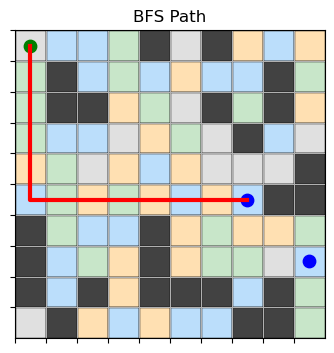

In [33]:
def bfs(start,goals):
    t0=time.time()
    q=deque([(start,[start],0)])
    visited={start}
    nodes=0
    while q:
        pos,path,cost=q.popleft()
        nodes+=1
        if pos in goals:
            return path,nodes,cost,time.time()-t0
        for nxt in get_neighbors(pos):
            if nxt not in visited:
                visited.add(nxt)
                q.append((nxt,path+[nxt],cost+COST[grid[nxt[0]][nxt[1]]]))
    return [],nodes,float('inf'),time.time()-t0
path,nodes,cost,tt=bfs(start,goals)
print("\nBFS RESULTS")
print_path_coords(path, "BFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: YES (shortest steps, not cost-aware)")
visualize(path,"BFS")
draw_path(path, "BFS Path")


DFS RESULTS

DFS coordinate path:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (0, 7), (0, 8), (0, 9), (1, 9), (2, 9), (3, 9), (3, 8), (4, 8), (4, 7), (4, 6), (4, 5), (4, 4), (4, 3), (4, 2), (4, 1), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
Path Length: 33
Cost: 63
Nodes Explored: 93
Execution Time: 0.00028 sec
Optimal: NO

DFS PATH
S * * * X C X * * *
O X L * * * * * X *
O X X S O C X O X *
O L L C S O C X * *
* * * * * * * * * X
* * * * * * * G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


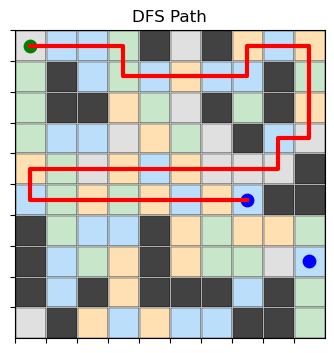

In [34]:
def dfs(start,goals):
    t0=time.time()
    stack=[(start,[start],0)]
    visited=set()
    nodes=0
    while stack:
        pos,path,cost=stack.pop()
        nodes+=1
        if pos in goals:
            return path,nodes,cost,time.time()-t0
        if pos in visited: continue
        visited.add(pos)
        for nxt in get_neighbors(pos):
            stack.append((nxt,path+[nxt],cost+COST[grid[nxt[0]][nxt[1]]]))
    return [],nodes,float('inf'),time.time()-t0
path,nodes,cost,tt=dfs(start,goals)
print("\nDFS RESULTS")
print_path_coords(path, "DFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: NO")
visualize(path,"DFS")
draw_path(path, "DFS Path")


BestFS RESULTS

BestFS coordinate path:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (0, 7), (0, 8), (0, 9), (1, 9), (2, 9), (3, 9), (3, 8), (4, 8), (4, 7), (5, 7)]
Path Length: 19
Cost: 34
Nodes Explored: 25
Execution Time: 0.0003 sec
Optimal: NO (heuristic only)

BestFS PATH
S * * * X C X * * *
O X L * * * * * X *
O X X S O C X O X *
O L L C S O C X * *
S O C S L S C * * X
L O S O S L S G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


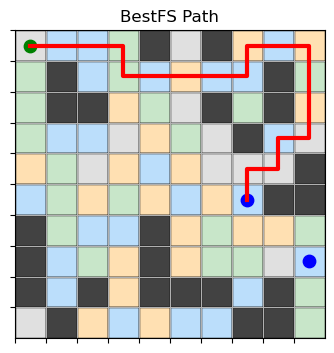

In [35]:
def bestfs(start,goals,heuristic):
    t0=time.time()
    pq=[]
    goal=goals[0]
    heapq.heappush(pq,(0,start,[start],0))
    visited=set()
    nodes=0
    while pq:
        _,pos,path,cost=heapq.heappop(pq)
        nodes+=1
        if pos in goals:
            return path,nodes,cost,time.time()-t0
        if pos in visited: continue
        visited.add(pos)
        for nxt in get_neighbors(pos):
            heapq.heappush(pq,(heuristic(nxt,goal),nxt,path+[nxt],cost+COST[grid[nxt[0]][nxt[1]]]))
    return [],nodes,float('inf'),time.time()-t0
path,nodes,cost,tt=bestfs(start,goals,manhattan)
print("\nBestFS RESULTS")
print_path_coords(path, "BestFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: NO (heuristic only)")
visualize(path,"BestFS")
draw_path(path, "BestFS Path")


A* RESULTS

A* coordinate path:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4), (2, 5), (3, 5), (3, 6), (4, 6), (4, 7), (5, 7)]
Path Length: 13
Cost: 16
Nodes Explored: 61
Execution Time: 0.00053 sec
Optimal: YES (cost + heuristic)

A* PATH
S * * * X C X S L S
O X L * * S L L X O
O X X S * * X O X S
O L L C S * * X L C
S O C S L S * * C X
L O S O S L S G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


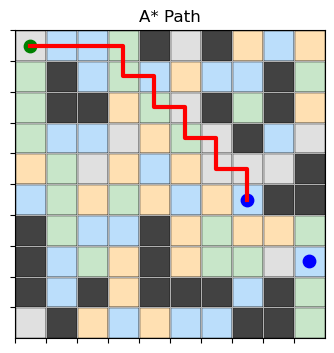

In [36]:
def astar(start,goals,heuristic):
    t0=time.time()
    pq=[]
    goal=goals[0]
    heapq.heappush(pq,(0,start,[start],0))
    visited={}
    nodes=0
    while pq:
        f,pos,path,g=heapq.heappop(pq)
        nodes+=1
        if pos in goals:
            return path,nodes,g,time.time()-t0
        if pos in visited and visited[pos]<=g: continue
        visited[pos]=g
        for nxt in get_neighbors(pos):
            ng=g+COST[grid[nxt[0]][nxt[1]]]
            heapq.heappush(pq,(ng+heuristic(nxt,goal),nxt,path+[nxt],ng))
    return [],nodes,float('inf'),time.time()-t0
path,nodes,cost,tt=astar(start,goals,manhattan)
print("\nA* RESULTS")
print_path_coords(path, "A*")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: YES (cost + heuristic)")
visualize(path,"A*")
draw_path(path, "A* Path")


Applying dynamic emergency blocking...

GRID AFTER BLOCKING:
C L L O X C X S L S
O X L O X S L L X O
O X X S X C X O X S
O L L C S O C X L C
S O C S L S X C C X
L O S O S L S L X X
X O L L X S O S S O
X L O S X S O O C L
X L X S X X X L X O
C X S L S L L X X O


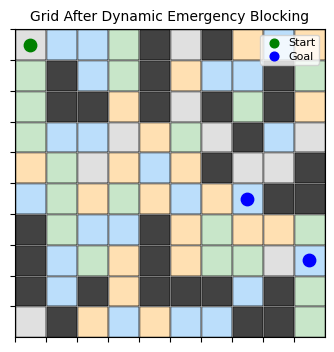

In [37]:
def dynamic_block(path):
    if len(path) < 3:
        return
    for _ in range(random.randint(3,5)):
        r,c = random.choice(path[1:-1])
        grid[r][c] = 'X'
print("\nApplying dynamic emergency blocking...")
dynamic_block(path)   # 'path' is from last A* run
print("\nGRID AFTER BLOCKING:")
print_grid(grid)
draw_grid("Grid After Dynamic Emergency Blocking")


BFS AFTER BLOCKING

BFS coordinate path:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
Path Length: 13
Cost: 23
Nodes Explored: 46
Execution Time: 0.00022 sec
Optimal: YES (shortest steps only)

BFS After Block PATH
S L L O X C X S L S
* X L O X S L L X O
* X X S X C X O X S
* L L C S O C X L C
* O C S L S X C C X
* * * * * * * G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


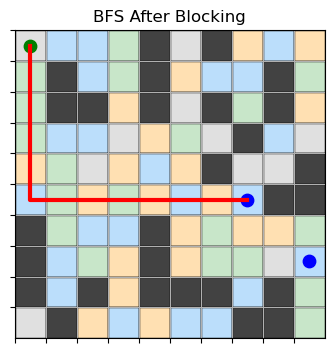

In [38]:
path,nodes,cost,tt = bfs(start,goals)
print("\nBFS AFTER BLOCKING")
print_path_coords(path, "BFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: YES (shortest steps only)")
visualize(path,"BFS After Block")
draw_path(path, "BFS After Blocking")


DFS AFTER BLOCKING

DFS coordinate path:
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (3, 3), (3, 2), (3, 1), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (0, 7), (0, 8), (0, 9), (1, 9), (2, 9), (3, 9), (3, 8), (4, 8), (4, 7), (5, 7)]
Path Length: 31
Cost: 56
Nodes Explored: 64
Execution Time: 0.00025 sec
Optimal: NO

DFS After Block PATH
S * * * X C X * * *
O X L * X * * * X *
O X X * X * X O X *
* * * * S * C X * *
* * * * * * X * * X
L O S O S L S G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


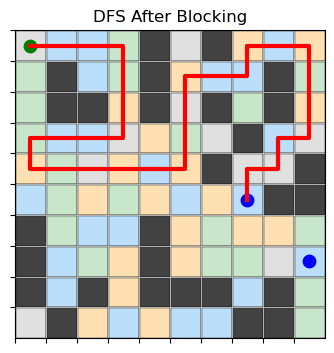

In [39]:
path,nodes,cost,tt = dfs(start,goals)
print("\nDFS AFTER BLOCKING")
print_path_coords(path, "DFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: NO")
visualize(path,"DFS After Block")
draw_path(path, "DFS After Blocking")


BestFS AFTER BLOCKING (Custom Heuristic)

BestFS coordinate path:
[(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1), (5, 1), (6, 1), (6, 2), (6, 3), (5, 3), (5, 4), (5, 5), (5, 6), (6, 6), (7, 6), (7, 7), (7, 8), (7, 9)]
Path Length: 19
Cost: 27
Nodes Explored: 41
Execution Time: 0.00038 sec
Optimal: NO (heuristic only)

BestFS After Block PATH
S L L O X C X S L S
* X L O X S L L X O
* X X S X C X O X S
* * L C S O C X L C
S * C S L S X C C X
L * S * * * * G X X
X * * * X S * S S O
X L O S X S * * * G
X L X S X X X L X O
C X S L S L L X X O


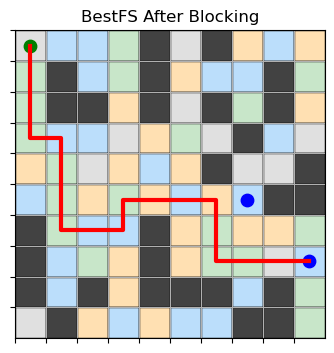

In [40]:
path,nodes,cost,tt = bestfs(start,goals,custom_heuristic)
print("\nBestFS AFTER BLOCKING (Custom Heuristic)")
print_path_coords(path, "BestFS")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: NO (heuristic only)")
visualize(path,"BestFS After Block")
draw_path(path, "BestFS After Blocking")


A* AFTER BLOCKING (Custom Heuristic)

A* coordinate path:
[(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (4, 1), (4, 2), (4, 3), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7)]
Path Length: 13
Cost: 21
Nodes Explored: 112
Execution Time: 0.00047 sec
Optimal: YES (cost + heuristic)

A* After Block PATH
S L L O X C X S L S
* X L O X S L L X O
* X X S X C X O X S
* * L C S O C X L C
S * * * L S X C C X
L O S * * * * G X X
X O L L X S O S S O
X L O S X S O O C G
X L X S X X X L X O
C X S L S L L X X O


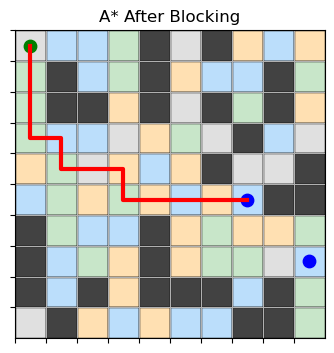

In [41]:
path,nodes,cost,tt = astar(start,goals,custom_heuristic)
print("\nA* AFTER BLOCKING (Custom Heuristic)")
print_path_coords(path, "A*")
print("Path Length:",len(path))
print("Cost:",cost)
print("Nodes Explored:",nodes)
print("Execution Time:",round(tt,5),"sec")
print("Optimal: YES (cost + heuristic)")
visualize(path,"A* After Block")
draw_path(path, "A* After Blocking")